# Bari- Hybrid Multimodal Anemia Detection System


**Components:**
1. **Tabular Model**
2. **Visual Model**
3. **Late Fusion**



## 1. Imports & Configuration

In [97]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



#  Part 1: Tabular Model 

Process CBC blood test data

## 1. Data Loading

In [ ]:

df = pd.read_csv(r"C:\Users\USER\Capstone\Bari\data\Tabular\anemia.csv")
df.head()

print("Dataset Shape:", df.shape)

df.info()

df.describe()

missing = df.isnull().sum()
print(missing)


Dataset Shape: (710, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 710 entries, 0 to 709
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   IMAGE_ID               710 non-null    object 
 1   HB_LEVEL               710 non-null    float64
 2   Severity               710 non-null    object 
 3   Age(Months)            710 non-null    int64  
 4   GENDER                 710 non-null    object 
 5   REMARK                 710 non-null    object 
 6   HOSPITAL               710 non-null    object 
 7   CITY/TOWN              710 non-null    object 
 8   MUNICIPALITY/DISTRICT  710 non-null    object 
 9   REGION                 710 non-null    object 
 10  COUNTRY                710 non-null    object 
dtypes: float64(1), int64(1), object(9)
memory usage: 61.1+ KB
IMAGE_ID                 0
HB_LEVEL                 0
Severity                 0
Age(Months)              0
GENDER                 

## 2. Data Cleaning and Preprocessing

In [ ]:
print(df.columns)

Index(['IMAGE_ID', 'HB_LEVEL', 'Severity', 'Age(Months)', 'GENDER', 'REMARK',
       'HOSPITAL', 'CITY/TOWN', 'MUNICIPALITY/DISTRICT', 'REGION', 'COUNTRY'],
      dtype='object')


In [ ]:
df['Age_Years'] = df['Age(Months)'] / 12

Categorical columns: ['IMAGE_ID', 'Severity', 'GENDER', 'REMARK', 'HOSPITAL', 'CITY/TOWN', 'MUNICIPALITY/DISTRICT', 'REGION', 'COUNTRY']
Encoded categorical columns.


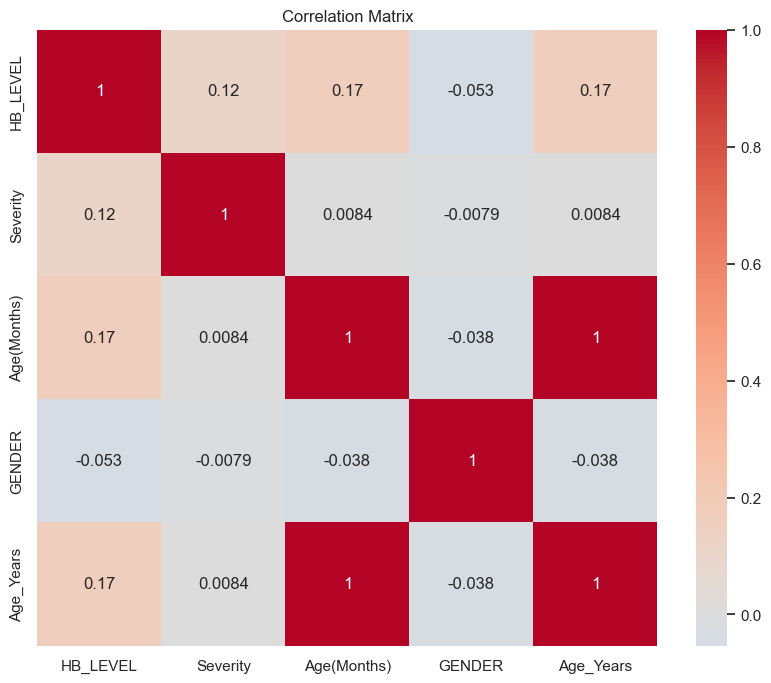

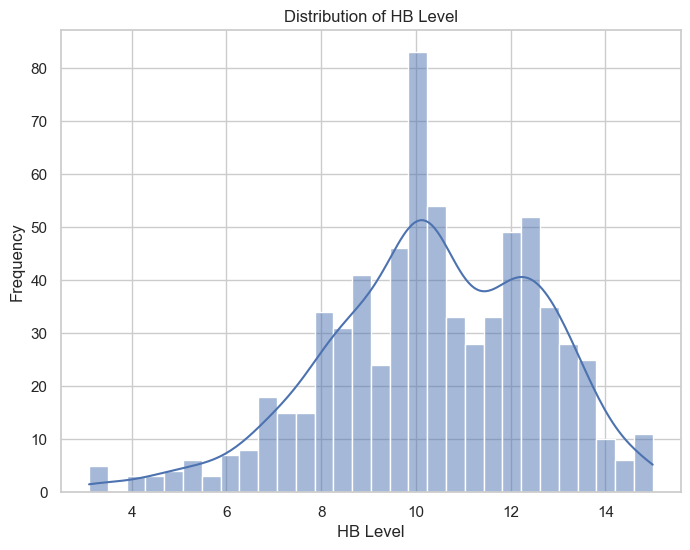

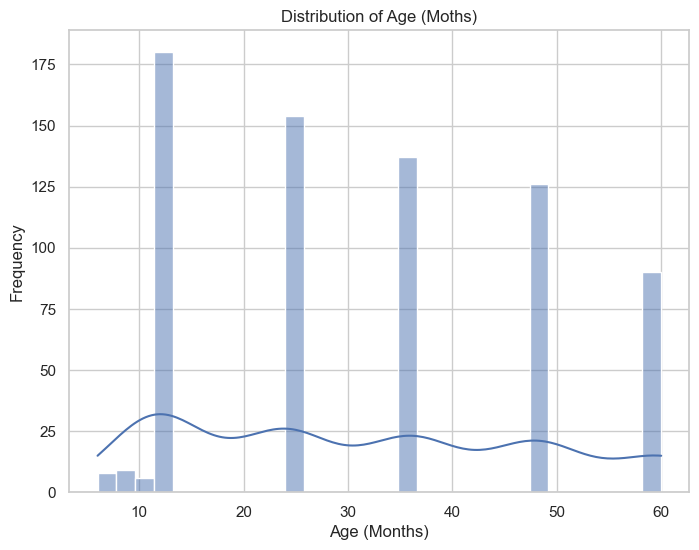


Skewness of HB_LEVEL: -0.4303898205250962
Skewness of Age (Years): 0.27475039611988206


In [101]:
from sklearn.preprocessing import LabelEncoder

# Step 1: Clean column names (strip whitespace)
df.columns = df.columns.str.strip()

# Step 2: Identify categorical columns (e.g., GENDER, HOSPITAL, etc.)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns:", categorical_cols)

# Step 3: Encode all categorical columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # Store if needed later
print("Encoded categorical columns.")

# Step 4: Drop unused columns (e.g., metadata)
columns_to_drop = ['IMAGE_ID', 'REMARK', 'HOSPITAL', 'CITY/TOWN', 'MUNICIPALITY/DISTRICT', 'REGION', 'COUNTRY']  # Adjust as needed
df.drop(columns=columns_to_drop,inplace=True)

# Step 5: Compute correlation matrix
corr_matrix = df.corr()

# Plot correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

# Step 6: Visualize distributions
# Histogram for HB_LEVEL
plt.figure(figsize=(8, 6))
sns.histplot(df['HB_LEVEL'], kde=True, bins=30)
plt.title('Distribution of HB Level')
plt.xlabel('HB Level')
plt.ylabel('Frequency')
plt.show()

# Histogram for Age
plt.figure(figsize=(8, 6))
sns.histplot(df['Age(Months)'], kde=True, bins=30)
plt.title('Distribution of Age (Moths)')
plt.xlabel('Age (Months)')
plt.ylabel('Frequency')
plt.show()

# Step 7: Check for outliers or skew
# For example, check skewness
print("\nSkewness of HB_LEVEL:", df['HB_LEVEL'].skew())
print("Skewness of Age (Years):", df['Age_Years'].skew())

# Once satisfied, you can proceed with stratified 5-fold cross-validation

In [102]:
def map_severity(row):
    hb = row["HB_LEVEL"]
    age = row["Age_Years"]
    gender = str(row["GENDER"]).strip().lower()

    # Children 6–59 months (0.5–5 years)
    if 0.5 <= age < 5:
        if hb >= 11:
            return "Normal"
        elif 10 <= hb < 11:
            return "Mild"
        elif 7 <= hb < 10:
            return "Moderate"
        else:
            return "Severe"

    # Children 5–11 years
    elif 5 <= age < 12:
        if hb >= 11.5:
            return "Normal"
        elif 11 <= hb < 11.5:
            return "Mild"
        elif 8 <= hb < 11:
            return "Moderate"
        else:
            return "Severe"

    # Adolescents 12–14 years
    elif 12 <= age < 15:
        if hb >= 12:
            return "Normal"
        elif 11 <= hb < 12:
            return "Mild"
        elif 8 <= hb < 11:
            return "Moderate"
        else:
            return "Severe"

    # Adult women
    elif age >= 15 and gender == "female":
        if hb >= 12:
            return "Normal"
        elif 11 <= hb < 12:
            return "Mild"
        elif 8 <= hb < 11:
            return "Moderate"
        else:
            return "Severe"

    # Adult men
    elif age >= 15 and gender == "male":
        if hb >= 13:
            return "Normal"
        elif 11 <= hb < 13:
            return "Mild"
        elif 8 <= hb < 11:
            return "Moderate"
        else:
            return "Severe"

    return "Unknown"

# Overwrite severity using WHO mapping
df["Severity_WHO"] = df.apply(map_severity, axis=1)

print(df["Severity_WHO"].value_counts())

Severity_WHO
Normal      282
Moderate    242
Mild        132
Severe       54
Name: count, dtype: int64


In [103]:
print("Overall HB statistics:")
print(df["HB_LEVEL"].describe())

Overall HB statistics:
count    710.000000
mean      10.358521
std        2.258663
min        3.100000
25%        8.900000
50%       10.300000
75%       12.100000
max       15.000000
Name: HB_LEVEL, dtype: float64


In [104]:
import numpy as np

# Add a small constant to avoid log(0)
df['HB_LOG'] = np.log(df['HB_LEVEL'] + 1)

# Check the new skewness
print("New skewness of HB_LOG:", df['HB_LOG'].skew())

New skewness of HB_LOG: -1.224896772766387


In [105]:
mean_hb_by_severity = df.groupby("Severity_WHO")["HB_LEVEL"].mean()
print("\nMean HB per Severity:")
print(mean_hb_by_severity)


Mean HB per Severity:
Severity_WHO
Mild        10.363939
Moderate     8.823347
Normal      12.553404
Severe       5.762963
Name: HB_LEVEL, dtype: float64


In [106]:
mean_hb_by_gender = df.groupby("GENDER")["HB_LEVEL"].mean()
print("\nMean HB per Gender:")
print(mean_hb_by_gender)


Mean HB per Gender:
GENDER
0    10.496797
1    10.253787
Name: HB_LEVEL, dtype: float64


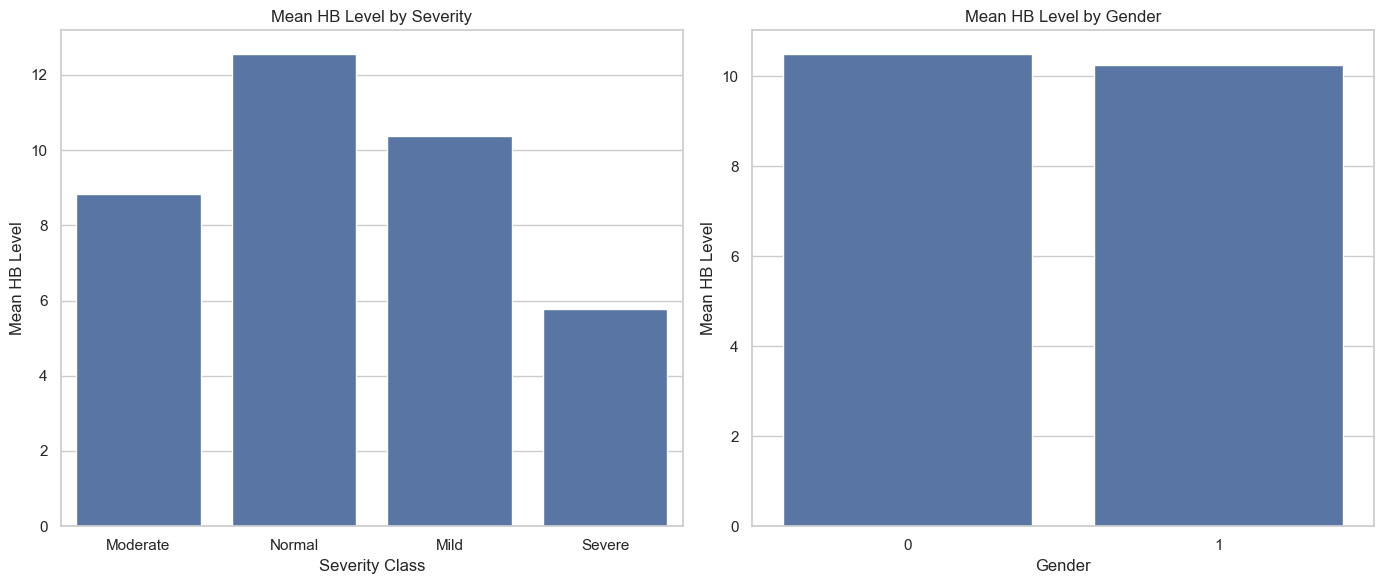

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot mean HB by severity class
sns.barplot(x='Severity_WHO', y='HB_LEVEL', data=df, estimator='mean', errorbar=None, ax=axes[0])
axes[0].set_title('Mean HB Level by Severity')
axes[0].set_xlabel('Severity Class')
axes[0].set_ylabel('Mean HB Level')

# Plot mean HB by gender
sns.barplot(x='GENDER', y='HB_LEVEL', data=df, estimator='mean', errorbar=None, ax=axes[1])
axes[1].set_title('Mean HB Level by Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Mean HB Level')

plt.tight_layout()
plt.show()

## Data splitting & modelling


In [108]:
from sklearn.preprocessing import LabelEncoder

# Create encoder
le = LabelEncoder()

# Fit on the target
y_encoded = le.fit_transform(ml_df[target])

# Check mapping
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Mild': 0, 'Moderate': 1, 'Normal': 2, 'Severe': 3}


In [109]:
import pandas as pd
import numpy as np

# Features and target
features = ["HB_LEVEL", "Age_Years", "GENDER"]
target = "Severity_WHO"

ml_df = df[features + [target]].copy()

# One-hot encode Gender
ml_df = pd.get_dummies(ml_df, columns=['GENDER'], drop_first=True)

# Split features and target
X = ml_df.drop(columns=[target])
y = y_encoded

2    282
1    242
0    132
3     54
Name: count, dtype: int64


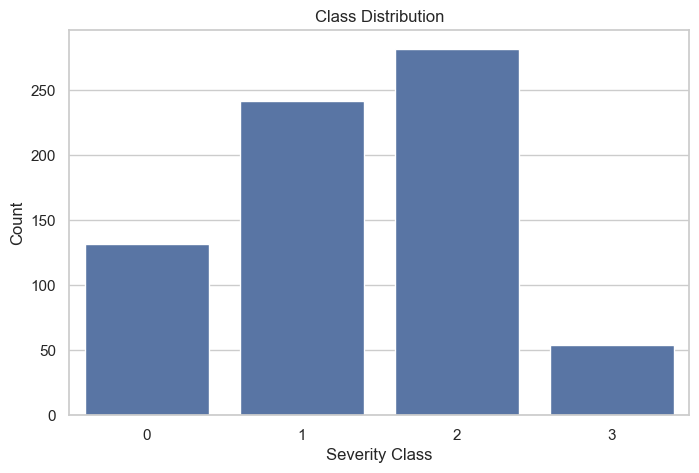

In [110]:
import pandas as pd
# Check class distribution
y_series = pd.Series(y)
class_counts = y_series.value_counts()
print(class_counts)

# Optionally, plot it
import seaborn as sns
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title('Class Distribution')
plt.xlabel('Severity Class')
plt.ylabel('Count')
plt.show()

In [111]:
from sklearn.preprocessing import LabelEncoder

# Create encoder
le = LabelEncoder()

# Fit on the target
y_encoded = le.fit_transform(ml_df[target])

# Check mapping
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Mild': 0, 'Moderate': 1, 'Normal': 2, 'Severe': 3}


In [112]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))
print("Class weights:", class_weights)

Class weights: {0: 1.3523809523809525, 1: 0.7319587628865979, 2: 0.6283185840707964, 3: 3.302325581395349}


In [113]:
# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# XGBoost
from xgboost import XGBClassifier

# Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical


lr_model = LogisticRegression(
    solver='lbfgs',
    class_weight='balanced',
    max_iter=1000
)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

print(" Logistic Regression")
print(classification_report(y_test, y_pred_lr))

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

print(" Random Forest")
print(classification_report(y_test, y_pred_rf))

xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=len(classes),
    eval_metric='mlogloss',
    use_label_encoder=False
)
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)

print(" XGBoost ")
print(classification_report(y_test, y_pred_xgb))


# One-hot encode target
y_train_cat = to_categorical(pd.Categorical(y_train, categories=classes).codes)
y_test_cat = to_categorical(pd.Categorical(y_test, categories=classes).codes)

# Map class weights for Keras
class_weights_keras = {i: w for i, w in enumerate(weights)}

# Define model
nn_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(len(classes), activation='softmax')
])

nn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train model
history = nn_model.fit(
    X_train_scaled, y_train_cat,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights_keras,
    verbose=1
)

# Evaluate
test_loss, test_acc = nn_model.evaluate(X_test_scaled, y_test_cat)
print("Neural Network ")
print("Test Accuracy:", test_acc)

 Logistic Regression
              precision    recall  f1-score   support

           0       0.69      1.00      0.82        27
           1       0.97      0.77      0.86        48
           2       1.00      0.93      0.96        56
           3       0.77      0.91      0.83        11

    accuracy                           0.89       142
   macro avg       0.86      0.90      0.87       142
weighted avg       0.91      0.89      0.89       142

 Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       0.98      0.96      0.97        48
           2       1.00      1.00      1.00        56
           3       0.83      0.91      0.87        11

    accuracy                           0.98       142
   macro avg       0.95      0.97      0.96       142
weighted avg       0.98      0.98      0.98       142



C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:200: UserWarning: [11:46:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 XGBoost 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00        48
           2       1.00      1.00      1.00        56
           3       1.00      1.00      1.00        11

    accuracy                           1.00       142
   macro avg       1.00      1.00      1.00       142
weighted avg       1.00      1.00      1.00       142



C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 99ms/step - accuracy: 0.3062 - loss: 1.3997 - val_accuracy: 0.5000 - val_loss: 1.3220
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.4273 - loss: 1.3065 - val_accuracy: 0.5175 - val_loss: 1.2747
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.4846 - loss: 1.2505 - val_accuracy: 0.5263 - val_loss: 1.2160
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5198 - loss: 1.1632 - val_accuracy: 0.5175 - val_loss: 1.1598
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5286 - loss: 1.1355 - val_accuracy: 0.5175 - val_loss: 1.0992
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5198 - loss: 1.0928 - val_accuracy: 0.5175 - val_loss: 1.0276
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5308 - loss: 1.0349 - val_accuracy: 0.5175 - val_loss: 0.9613
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5815 - loss: 0.9416 - val_accuracy: 0.5263 - 

Logistic Regression
              precision    recall  f1-score   support

           0       0.69      1.00      0.82        27
           1       0.97      0.77      0.86        48
           2       1.00      0.93      0.96        56
           3       0.77      0.91      0.83        11

    accuracy                           0.89       142
   macro avg       0.86      0.90      0.87       142
weighted avg       0.91      0.89      0.89       142



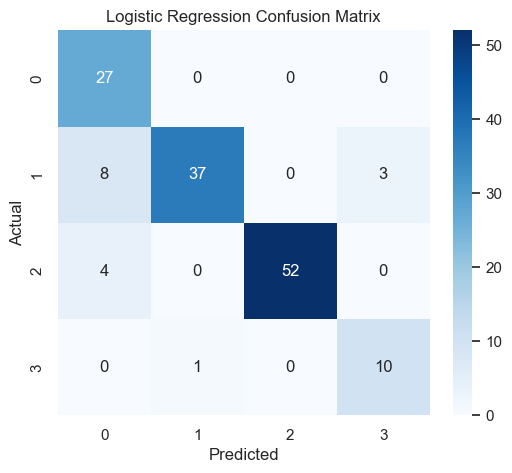

Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       0.98      0.96      0.97        48
           2       1.00      1.00      1.00        56
           3       0.83      0.91      0.87        11

    accuracy                           0.98       142
   macro avg       0.95      0.97      0.96       142
weighted avg       0.98      0.98      0.98       142



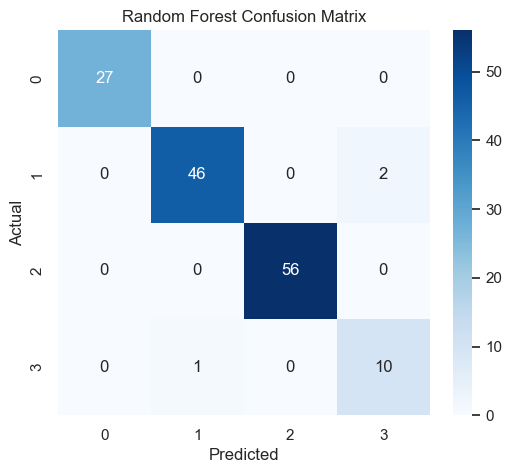

XGBoost
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00        48
           2       1.00      1.00      1.00        56
           3       1.00      1.00      1.00        11

    accuracy                           1.00       142
   macro avg       1.00      1.00      1.00       142
weighted avg       1.00      1.00      1.00       142



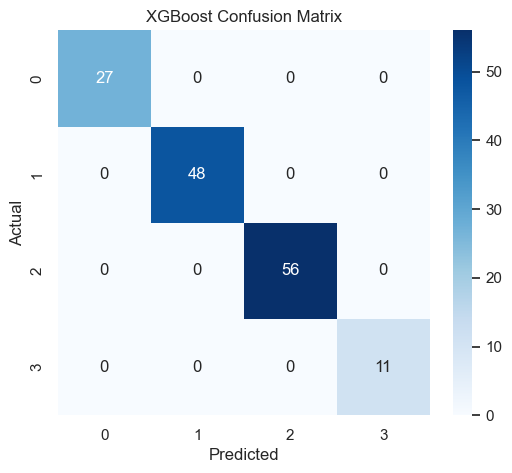

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/stepWARNING:tensorflow:5 out of the last 16 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000002543789A5C0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Neural Network
              precision    recall  f1-score   support

           0       0.83      0.89      0.86        27
           1       1.00      0.81      0.90        48
           2       0.95      0.98      0.96        56
           3       0.69      1.00      0.81        11

    accuracy                           0.91       142
   macro avg       0.87      0.92      0.88       142
weighted avg       0.92      0.91      0.91       142



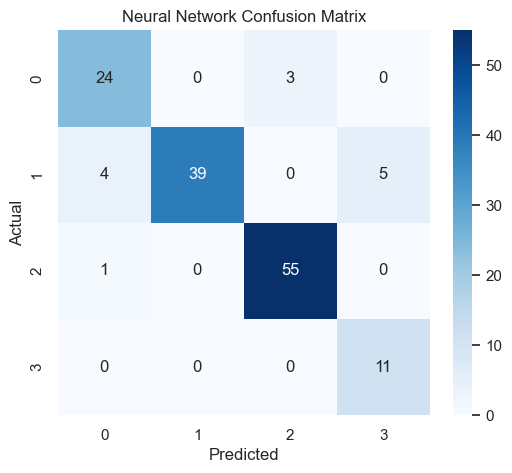


Model Comparison


,Accuracy,Macro F1
Logistic Regression,0.887324,0.868736
Random Forest,0.978873,0.959497
XGBoost,1.000000,1.000000
Neural Network,0.908451,0.883355


In [114]:
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Helper function to plot confusion matrix
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title(title)
    plt.show()

# Initialize summary dictionary
summary_results = {}

# Logistic Regression
print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))
plot_conf_matrix(y_test, y_pred_lr, "Logistic Regression Confusion Matrix")
summary_results['Logistic Regression'] = {
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Macro F1': classification_report(y_test, y_pred_lr, output_dict=True)['macro avg']['f1-score']
}

# Random Forest
print("Random Forest")
print(classification_report(y_test, y_pred_rf))
plot_conf_matrix(y_test, y_pred_rf, "Random Forest Confusion Matrix")
summary_results['Random Forest'] = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Macro F1': classification_report(y_test, y_pred_rf, output_dict=True)['macro avg']['f1-score']
}

# XGBoost
print("XGBoost")
print(classification_report(y_test, y_pred_xgb))
plot_conf_matrix(y_test, y_pred_xgb, "XGBoost Confusion Matrix")
summary_results['XGBoost'] = {
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'Macro F1': classification_report(y_test, y_pred_xgb, output_dict=True)['macro avg']['f1-score']
}

# Neural Network
# Predict classes from softmax probabilities
y_pred_nn_probs = nn_model.predict(X_test_scaled)
y_pred_nn_classes = classes[np.argmax(y_pred_nn_probs, axis=1)]

print("Neural Network")
print(classification_report(y_test, y_pred_nn_classes))
plot_conf_matrix(y_test, y_pred_nn_classes, "Neural Network Confusion Matrix")
summary_results['Neural Network'] = {
    'Accuracy': accuracy_score(y_test, y_pred_nn_classes),
    'Macro F1': classification_report(y_test, y_pred_nn_classes, output_dict=True)['macro avg']['f1-score']
}

# Summary table
summary_df = pd.DataFrame(summary_results).T
print("\nModel Comparison")
display(summary_df)

In [115]:
# Check test set shapes
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# After each model's prediction, check a few pairs
y_pred_lr = lr_model.predict(X_test_scaled)
print("Sample predictions (Logistic Regression):")
print(list(zip(y_test[:5], y_pred_lr[:5])))

y_pred_rf = rf_model.predict(X_test_scaled)
print("Sample predictions (Random Forest):")
print(list(zip(y_test[:5], y_pred_rf[:5])))

y_pred_xgb = xgb_model.predict(X_test_scaled)
print("Sample predictions (XGBoost):")
print(list(zip(y_test[:5], y_pred_xgb[:5])))

y_pred_nn_probs = nn_model.predict(X_test_scaled)
y_pred_nn_classes = classes[np.argmax(y_pred_nn_probs, axis=1)]
print("Sample predictions (Neural Network):")
print(list(zip(y_test[:5], y_pred_nn_classes[:5])))

X_test shape: (142, 3)
y_test shape: (142,)
Sample predictions (Logistic Regression):
[(1, 1), (1, 1), (0, 0), (2, 2), (0, 0)]
Sample predictions (Random Forest):
[(1, 1), (1, 1), (0, 0), (2, 2), (0, 0)]
Sample predictions (XGBoost):
[(1, 1), (1, 1), (0, 0), (2, 2), (0, 0)]


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Sample predictions (Neural Network):
[(1, 1), (1, 1), (0, 0), (2, 2), (0, 0)]


In [116]:
%pip install pandas==2.0.3
import os
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb


from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

results_folder = "results"
os.makedirs(results_folder, exist_ok=True)

#  Logistic Regression Tuning

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs'],
    'max_iter': [500]
}

grid_lr = GridSearchCV(
    LogisticRegression(),
    param_grid_lr,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_lr.fit(X_train_scaled, y_train)
best_lr = grid_lr.best_estimator_

#  Random Forest Tuning

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

#  XGBoost Tuning

param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),
    param_grid_xgb,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_

# Evaluation + Saving


models = {
    "Tuned_Logistic_Regression": (best_lr, X_test_scaled),
    "Tuned_Random_Forest": (best_rf, X_test),
    "Tuned_XGBoost": (best_xgb, X_test)
}

summary_results = []

for name, (model, X_eval) in models.items():
    
    y_pred = model.predict(X_eval)
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    
    # Classification Report
    report = classification_report(y_test, y_pred)
    
    # Save classification report
    with open(os.path.join(results_folder, f"{name}_classification_report.txt"), "w") as f:
        f.write(report)
    
    # Confusion Matrix

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(f"{name} Confusion Matrix")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.savefig(os.path.join(results_folder, f"{name}_confusion_matrix.png"))
    plt.close()
    
    # Extract macro F1
    report_dict = classification_report(y_test, y_pred, output_dict=True)
    macro_f1 = report_dict['macro avg']['f1-score']
    
    summary_results.append({
        "Model": name,
        "Accuracy": acc,
        "Macro_F1": macro_f1
    })
    
    # Save model
    joblib.dump(model, os.path.join(results_folder, f"{name}.pkl"))


# Save Summary Table

summary_df = pd.DataFrame(summary_results)
summary_df.to_csv(os.path.join(results_folder, "tuned_model_comparison.csv"), index=False)

print("\n TUNNING COMPLETED ")
print(summary_df.sort_values(by="Macro_F1", ascending=False))


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\USER\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:200: UserWarning: [11:49:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 TUNNING COMPLETED 
                       Model  Accuracy  Macro_F1
2              Tuned_XGBoost  1.000000  1.000000
1        Tuned_Random_Forest  0.978873  0.959497
0  Tuned_Logistic_Regression  0.922535  0.896298



FINAL RANDOM FOREST PERFORMANCE
Test Accuracy: 0.9788732394366197
Test Macro F1: 0.9594965675057208

OVERFITTING CHECK
Cross-Validation Macro F1: 0.9808605470222427
Test Macro F1: 0.9594965675057208
Difference: 0.021363979516521914

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       0.98      0.96      0.97        48
           2       1.00      1.00      1.00        56
           3       0.83      0.91      0.87        11

    accuracy                           0.98       142
   macro avg       0.95      0.97      0.96       142
weighted avg       0.98      0.98      0.98       142



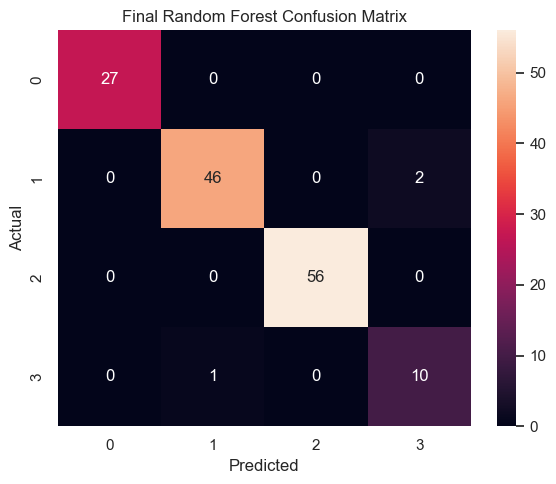


Number of Misclassified Samples: 3

FEATURE IMPORTANCE
     Feature  Importance
0   HB_LEVEL    0.939357
1  Age_Years    0.056078
2   GENDER_1    0.004564


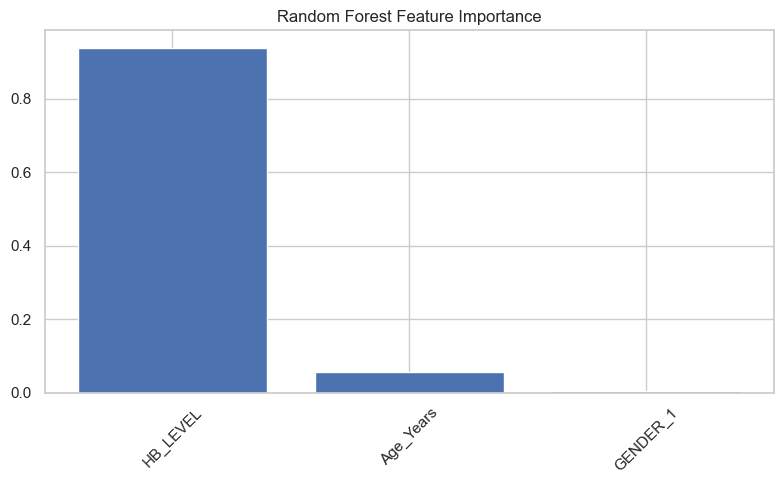


TABULAR MODEL FINALIZED SUCCESSFULLY


In [117]:
import os
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

results_folder = "results"
os.makedirs(results_folder, exist_ok=True)

# Predictions

y_pred_rf = best_rf.predict(X_test)

# Accuracy & Macro F1
accuracy = accuracy_score(y_test, y_pred_rf)
report_dict = classification_report(y_test, y_pred_rf, output_dict=True)
macro_f1 = report_dict['macro avg']['f1-score']

print("\nFINAL RANDOM FOREST PERFORMANCE")
print("Test Accuracy:", accuracy)
print("Test Macro F1:", macro_f1)

# Overfitting Analysis

cv_score = grid_rf.best_score_

print("\nOVERFITTING CHECK")
print("Cross-Validation Macro F1:", cv_score)
print("Test Macro F1:", macro_f1)
print("Difference:", abs(cv_score - macro_f1))

# Classification Report

report_text = classification_report(y_test, y_pred_rf)
print("\nCLASSIFICATION REPORT")
print(report_text)

with open(os.path.join(results_folder, "final_rf_classification_report.txt"), "w") as f:
    f.write(report_text)

# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=classes,
            yticklabels=classes)
plt.title("Final Random Forest Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig(os.path.join(results_folder, "final_rf_confusion_matrix.png"))
plt.show()

# Error Analysis

misclassified_idx = np.where(y_test != y_pred_rf)[0]
print("\nNumber of Misclassified Samples:", len(misclassified_idx))

# Feature Importance

importances = best_rf.feature_importances_
feature_names = X_train.columns

feat_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nFEATURE IMPORTANCE")
print(feat_df)

plt.figure(figsize=(8,5))
plt.bar(feat_df["Feature"], feat_df["Importance"])
plt.xticks(rotation=45)
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.savefig(os.path.join(results_folder, "final_rf_feature_importance.png"))
plt.show()

# Save feature importance CSV
feat_df.to_csv(os.path.join(results_folder, "final_rf_feature_importance.csv"), index=False)

# Save Model

joblib.dump(best_rf, os.path.join(results_folder, "final_random_forest.pkl"))

# Save Summary Table

summary_df = pd.DataFrame([{
    "Model": "Final Random Forest",
    "Test_Accuracy": accuracy,
    "Test_Macro_F1": macro_f1,
    "CV_Macro_F1": cv_score,
    "Overfitting_Gap": abs(cv_score - macro_f1)
}])

summary_df.to_csv(os.path.join(results_folder, "final_rf_summary.csv"), index=False)

print("\nTABULAR MODEL FINALIZED SUCCESSFULLY")


#  Part 2: Visual Model 

Process eye conjunctiva images 

In [118]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing import image_dataset_from_directory
from sklearn.metrics import confusion_matrix, classification_report

Found 710 files belonging to 2 classes.
Using 568 files for training.
Found 710 files belonging to 2 classes.
Using 142 files for validation.


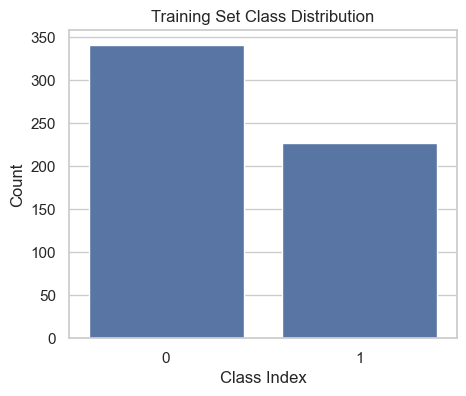

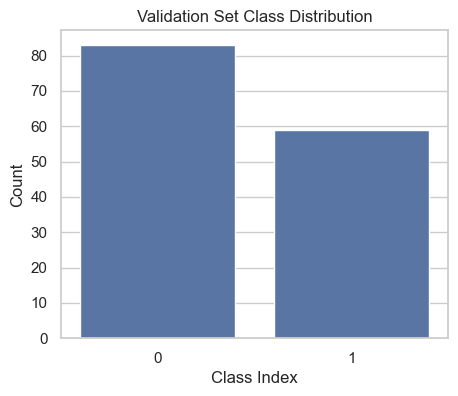

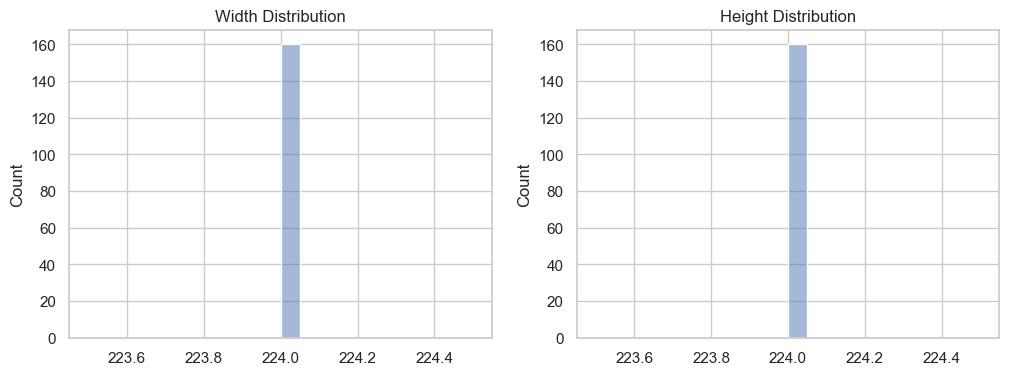

In [119]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
from tensorflow.keras import layers


# --- Paths ---
data_dir = r"C:\Users\USER\Capstone\Bari\data\Images"  
classes = ['Anemic', 'Non-Anemic']
img_size = (224, 224)
batch_size = 16
seed = 42
AUTOTUNE = tf.data.AUTOTUNE

# 1.Load Dataset

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

# 2 Check Class Distribution

def plot_class_distribution(dataset, title):
    labels = []
    for batch in dataset:
        _, y = batch
        labels.extend(y.numpy())
    plt.figure(figsize=(5,4))
    sns.countplot(x=labels)
    plt.title(title)
    plt.xlabel("Class Index")
    plt.ylabel("Count")
    plt.show()

plot_class_distribution(train_ds, "Training Set Class Distribution")
plot_class_distribution(val_ds, "Validation Set Class Distribution")

# 3. Check Image Dimensions Distribution

widths, heights = [], []
for batch in train_ds.take(10):  # sample few batches
    imgs, _ = batch
    for img in imgs:
        heights.append(img.shape[0])
        widths.append(img.shape[1])

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(widths, bins=20, kde=True)
plt.title("Width Distribution")
plt.subplot(1,2,2)
sns.histplot(heights, bins=20, kde=True)
plt.title("Height Distribution")
plt.show()

## Model Training

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 1,857,666 (7.09 MB)

 Non-trainable params: 402,880 (1.54 MB)

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.6180 - loss: 0.7196 - val_accuracy: 0.5915 - val_loss: 0.6901
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.8486 - loss: 0.3503 - val_accuracy: 0.6056 - val_loss: 0.7441
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.9225 - loss: 0.2071 - val_accuracy: 0.5915 - val_loss: 0.7982
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.9349 - loss: 0.1629 - val_accuracy: 0.5915 - val_loss: 1.3283
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.9630 - loss: 0.1164 - val_accuracy: 0.5986 - val_loss: 0.9797
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.9806 - loss: 0.0612 - val_accuracy: 0.6268 - val_loss: 0.8398


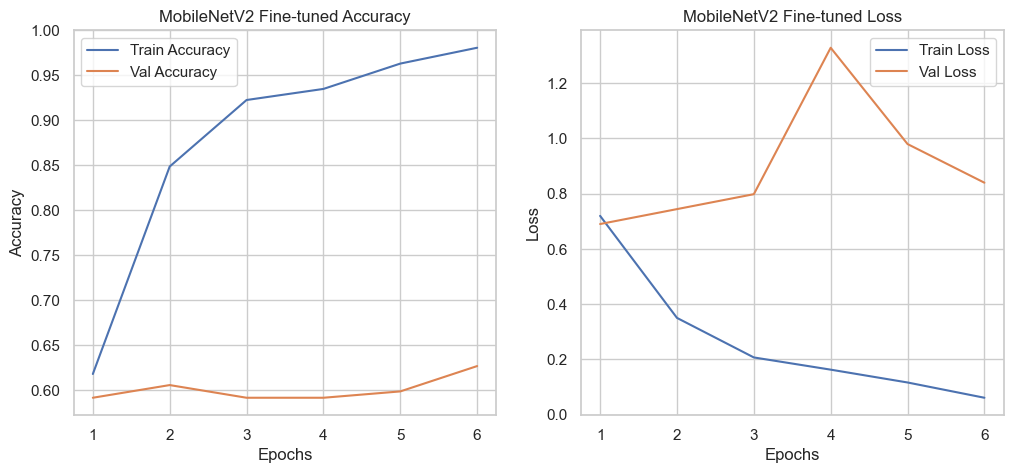

5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step

Validation Accuracy: 0.5915

Classification Report:
               precision    recall  f1-score   support

      Anemic       0.61      0.87      0.71        83
  Non-Anemic       0.52      0.20      0.29        59

    accuracy                           0.59       142
   macro avg       0.56      0.54      0.50       142
weighted avg       0.57      0.59      0.54       142



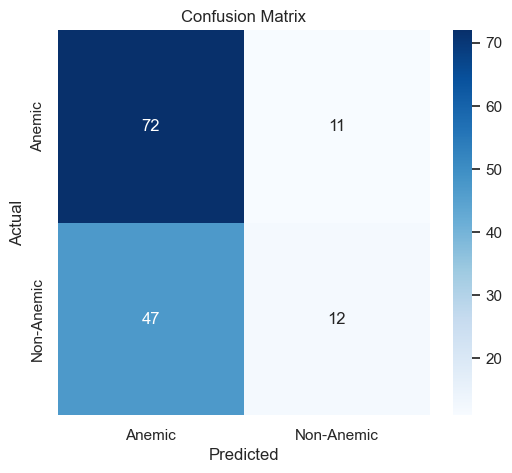

Visual model saved successfully!


In [120]:
import sklearn
import tensorflow as tf
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras import layers
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
])

# Prefetch for performance
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.prefetch(buffer_size=AUTOTUNE)

# -------------------------
# 2. Build MobileNetV2 base
# -------------------------
base_model = MobileNetV2(
    input_shape=img_size + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

# Freeze first 120 layers for fine-tuning
for layer in base_model.layers[:-50]:
    layer.trainable = False
for layer in base_model.layers[-50:]:
    layer.trainable = True

inputs = layers.Input(shape=img_size + (3,))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(len(classes), activation='softmax')(x)

model = models.Model(inputs, outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
# -------------------------
# 3. Train model with early stopping
# -------------------------
import tensorflow as tf

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)
# -------------------------
# 4. Plot training/validation curves
# -------------------------
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc)+1)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Val Accuracy')
plt.title("MobileNetV2 Fine-tuned Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Val Loss')
plt.title("MobileNetV2 Fine-tuned Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# -------------------------
# 5. Evaluate model on validation set
# -------------------------
val_images = []
val_labels = []

for batch_images, batch_labels in val_ds:
    val_images.append(batch_images.numpy())
    val_labels.append(batch_labels.numpy())

val_images = np.concatenate(val_images)
val_labels = np.concatenate(val_labels)

pred_probs = model.predict(val_images)
y_pred = np.argmax(pred_probs, axis=1)

print(f"\nValidation Accuracy: {accuracy_score(val_labels, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(val_labels, y_pred, target_names=classes))

cm = confusion_matrix(val_labels, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# -------------------------
# 6. Save model for later fusion
# -------------------------
model.save('mobilenetv2_finetuned_visual_model.h5')
print("Visual model saved successfully!")

## VALIDATION METRICS & VISUALIZATION

FULL FINE-TUNING &EVALUATION BLOCK

5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step 
Epoch 1/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.2389 - loss: 1.5824 - val_accuracy: 0.5517 - val_loss: 1.2366
Epoch 2/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3009 - loss: 1.4438 - val_accuracy: 0.3793 - val_loss: 1.2194
Epoch 3/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3009 - loss: 1.4234 - val_accuracy: 0.2414 - val_loss: 1.2335
Epoch 4/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.3540 - loss: 1.3616 - val_accuracy: 0.2759 - val_loss: 1.2286
Epoch 5/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4071 - loss: 1.2551 - val_accuracy: 0.4138 - val_loss: 1.1607
Epoch 6/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.3894 - loss: 1.2240 - val_accuracy: 0.4828 - val_loss: 1.1267
Epoch 7/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.3540 - loss: 1.2869 - val_accuracy: 0.4138 - val_loss: 1.1419
Epoch 8/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4779 - loss: 1.2245 - va

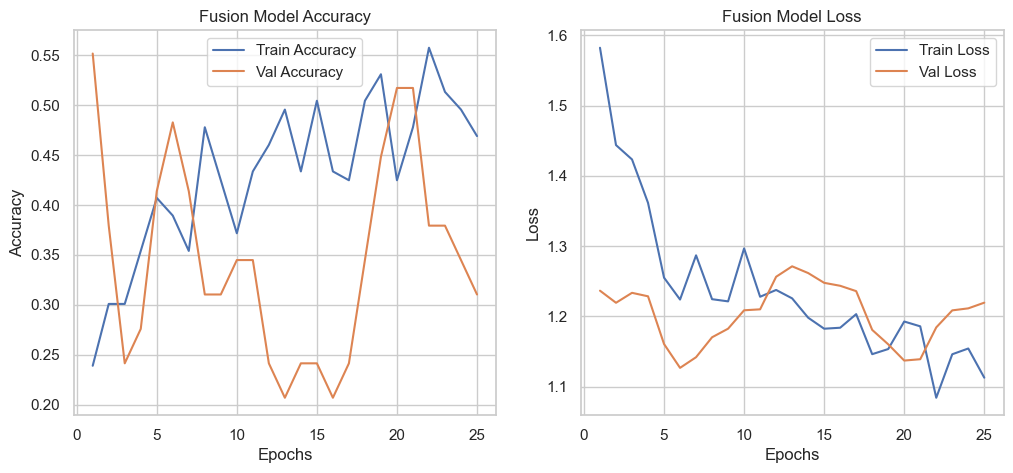

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

Fusion Model Accuracy: 0.5493

Classification Report:
               precision    recall  f1-score   support

      Severe       1.00      0.15      0.26        27
    Moderate       0.45      0.88      0.59        48
        Mild       0.73      0.57      0.64        56
      Normal       0.00      0.00      0.00        11

    accuracy                           0.55       142
   macro avg       0.54      0.40      0.37       142
weighted avg       0.63      0.55      0.50       142



C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classif

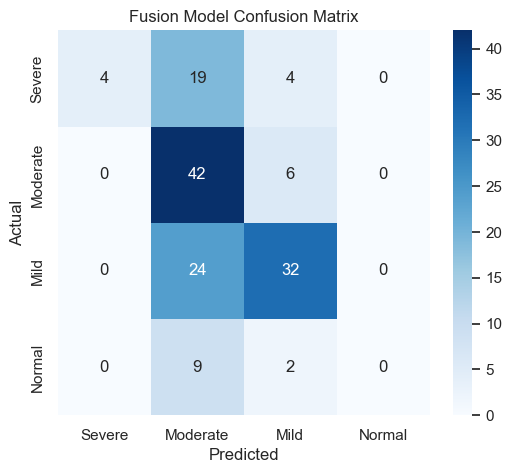


Sample 1:
Predicted_Class: Moderate
Severity: Moderate Anemia (7–9.9 g/dL)
Medical_Advice: Consult doctor for iron therapy if needed.
Symptoms: ['Fatigue', 'Paleness', 'Shortness of breath on exertion', 'Weakness']
Nutrition: ['Beans, lentils, spinach', 'Vitamin C foods: citrus, peppers', 'B12: eggs, dairy, fish', 'Folate: broccoli, leafy greens']
Exercise: ['Light to moderate activity okay', 'Avoid high-intensity workouts']

Sample 2:
Predicted_Class: Moderate
Severity: Moderate Anemia (7–9.9 g/dL)
Medical_Advice: Consult doctor for iron therapy if needed.
Symptoms: ['Fatigue', 'Paleness', 'Shortness of breath on exertion', 'Weakness']
Nutrition: ['Beans, lentils, spinach', 'Vitamin C foods: citrus, peppers', 'B12: eggs, dairy, fish', 'Folate: broccoli, leafy greens']
Exercise: ['Light to moderate activity okay', 'Avoid high-intensity workouts']

Sample 3:
Predicted_Class: Moderate
Severity: Moderate Anemia (7–9.9 g/dL)
Medical_Advice: Consult doctor for iron therapy if needed.
Sympt

In [122]:
# -------------------------
# TABULAR & IMAGE FUSION MODEL WITH NUTRITIONAL PLAN
# -------------------------

import tensorflow as tf
from tensorflow.keras import layers, models, Input
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------
# 0. Define anemia guidelines
# -------------------------
anemia_guidelines = {
    0: {  # Severe
        "severity": "Severe Anemia (<7 g/dL)",
        "medical_advice": "Immediate medical consultation required.",
        "symptoms": ["Extreme fatigue", "Shortness of breath", "Dizziness", "Pale skin", "Rapid heartbeat"],
        "nutrition": ["Red meat, liver, beans, lentils", "Vitamin C foods: oranges, peppers", "Folate: spinach, kale", "B12: eggs, dairy"],
        "exercise": ["Avoid strenuous exercise until cleared", "Light walking/stretching under supervision"]
    },
    1: {  # Moderate
        "severity": "Moderate Anemia (7–9.9 g/dL)",
        "medical_advice": "Consult doctor for iron therapy if needed.",
        "symptoms": ["Fatigue", "Paleness", "Shortness of breath on exertion", "Weakness"],
        "nutrition": ["Beans, lentils, spinach", "Vitamin C foods: citrus, peppers", "B12: eggs, dairy, fish", "Folate: broccoli, leafy greens"],
        "exercise": ["Light to moderate activity okay", "Avoid high-intensity workouts"]
    },
    2: {  # Mild
        "severity": "Mild Anemia (10–11.9 g/dL)",
        "medical_advice": "Maintain balanced diet, regular checkups recommended.",
        "symptoms": ["Tiredness", "Slight paleness", "Occasional dizziness"],
        "nutrition": ["Balanced diet with iron-rich foods", "Vitamin C to aid absorption", "Moderate red meat or plant-based iron"],
        "exercise": ["Normal activity okay", "Include regular aerobic activity"]
    },
    3: {  # Non-anemic
        "severity": "Non-Anemic (≥12 g/dL)",
        "medical_advice": "No treatment required.",
        "symptoms": [],
        "nutrition": ["Balanced diet with varied nutrients", "Iron from diet as needed"],
        "exercise": ["Regular exercise recommended"]
    }
}

# Define classes for fusion (severity levels)
classes = ['Severe', 'Moderate', 'Mild', 'Normal']

# 1. Prepare tabular embeddings (Random Forest predictions/probabilities)

tabular_probs = best_rf.predict_proba(X_test)  # shape: (num_samples, num_classes)


# 2. Extract image embeddings from fine-tuned MobileNetV2

feature_extractor = models.Model(
    inputs=model.inputs,
    outputs=model.layers[-3].output   # GlobalAveragePooling layer
)
image_embeddings = feature_extractor.predict(val_images)  # shape: (num_samples, embedding_dim)

# 3. Concatenate tabular + image features

fusion_input = np.concatenate([image_embeddings, tabular_probs], axis=1)
fusion_labels = y_test  # same as test labels

# 4. Build fusion neural network

input_dim = fusion_input.shape[1]
fusion_input_layer = Input(shape=(input_dim,))
x = layers.Dense(128, activation='relu')(fusion_input_layer)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.2)(x)
fusion_output = layers.Dense(len(classes), activation='softmax')(x)

fusion_model = models.Model(fusion_input_layer, fusion_output)
fusion_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# -------------------------
# 5. Train fusion model
# -------------------------
history_fusion = fusion_model.fit(
    fusion_input, fusion_labels,
    validation_split=0.2,
    epochs=25,
    batch_size=16
)

# -------------------------
# 6. Plot fusion training curves
# -------------------------
acc = history_fusion.history['accuracy']
val_acc = history_fusion.history['val_accuracy']
loss = history_fusion.history['loss']
val_loss = history_fusion.history['val_loss']
epochs_range = range(1, len(acc)+1)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Val Accuracy')
plt.title("Fusion Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Val Loss')
plt.title("Fusion Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# -------------------------
# 7. Evaluate fusion model
# -------------------------
fusion_preds = np.argmax(fusion_model.predict(fusion_input), axis=1)

print(f"\nFusion Model Accuracy: {accuracy_score(fusion_labels, fusion_preds):.4f}")
print("\nClassification Report:\n", classification_report(fusion_labels, fusion_preds, target_names=classes))

cm = confusion_matrix(fusion_labels, fusion_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Fusion Model Confusion Matrix")
plt.show()

# -------------------------
# 8. Map predictions to nutritional plan + exercise + symptoms
# -------------------------
results = []
for pred in fusion_preds:
    plan = anemia_guidelines[pred]
    results.append({
        "Predicted_Class": classes[pred],
        "Severity": plan["severity"],
        "Medical_Advice": plan["medical_advice"],
        "Symptoms": plan["symptoms"],
        "Nutrition": plan["nutrition"],
        "Exercise": plan["exercise"]
    })

# Example: print first 3 results
for i, r in enumerate(results[:3]):
    print(f"\nSample {i+1}:")
    for k, v in r.items():
        print(f"{k}: {v}")

# -------------------------
# 9. Save fusion model
# -------------------------
fusion_model.save('fusion_model_tabular_visual_with_plan.h5')
print("Fusion model with nutritional plan saved successfully!")

## 3. Fusion Layer

5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step 
Epoch 1/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step - accuracy: 0.1593 - loss: 1.9445 - val_accuracy: 0.1379 - val_loss: 1.5388
Epoch 2/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.2832 - loss: 1.6299 - val_accuracy: 0.3793 - val_loss: 1.3564
Epoch 3/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.3186 - loss: 1.4496 - val_accuracy: 0.2759 - val_loss: 1.3261
Epoch 4/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.3717 - loss: 1.3620 - val_accuracy: 0.3103 - val_loss: 1.3462
Epoch 5/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.3274 - loss: 1.4473 - val_accuracy: 0.3448 - val_loss: 1.3278
Epoch 6/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.3540 - loss: 1.3667 - val_accuracy: 0.3448 - val_loss: 1.3300
Epoch 7/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3982 - loss: 1.3605 - val_accuracy: 0.3448 - val_loss: 1.3155
Epoch 8/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.3894 - loss: 1.3401 - v

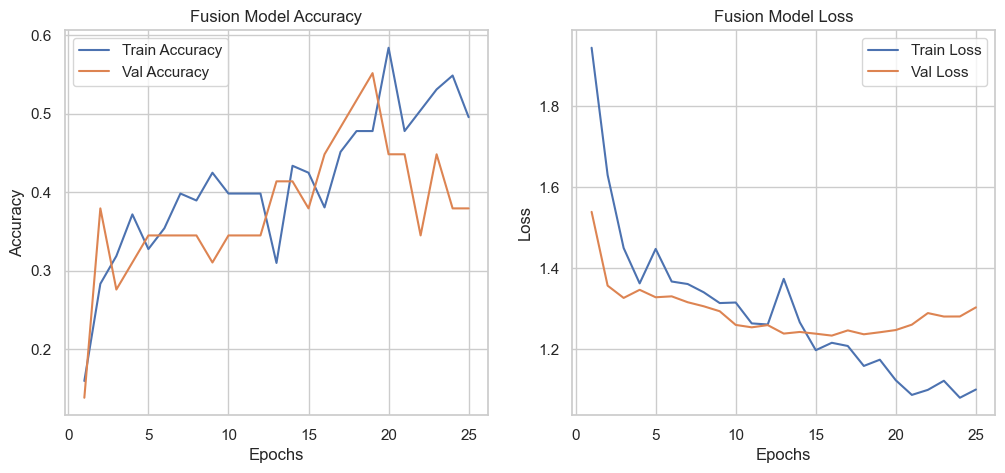

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

Fusion Model Accuracy: 0.5775

Classification Report:
               precision    recall  f1-score   support

      Severe       0.78      0.26      0.39        27
    Moderate       0.48      0.75      0.59        48
        Mild       0.67      0.68      0.67        56
      Normal       1.00      0.09      0.17        11

    accuracy                           0.58       142
   macro avg       0.73      0.44      0.45       142
weighted avg       0.65      0.58      0.55       142



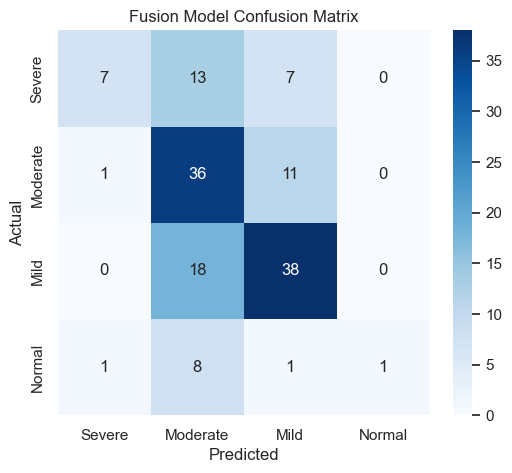

Fusion model saved successfully!


In [123]:
# TABULAR & IMAGE FUSION MODEL


import tensorflow as tf
from tensorflow.keras import layers, models, Input
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Prepare tabular embeddings (Random Forest predictions/probabilities) ---
tabular_probs = best_rf.predict_proba(X_test)

# --- 2. Extract image embeddings from fine-tuned MobileNetV2 ---
feature_extractor = models.Model(
    inputs=model.inputs,
    outputs=model.layers[-3].output   # GlobalAveragePooling layer
)

image_embeddings = feature_extractor.predict(val_images)

# --- 3. Concatenate tabular + image features ---
fusion_input = np.concatenate([image_embeddings, tabular_probs], axis=1)
fusion_labels = y_test  # same as test labels

# --- 4. Build fusion neural network ---
input_dim = fusion_input.shape[1]
fusion_input_layer = Input(shape=(input_dim,))
x = layers.Dense(128, activation='relu')(fusion_input_layer)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.2)(x)
fusion_output = layers.Dense(len(classes), activation='softmax')(x)

fusion_model = models.Model(fusion_input_layer, fusion_output)
fusion_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# --- 5. Train fusion model ---
history_fusion = fusion_model.fit(
    fusion_input, fusion_labels,
    validation_split=0.2,
    epochs=25,
    batch_size=16
)

# --- 6. Plot fusion training curves ---
acc = history_fusion.history['accuracy']
val_acc = history_fusion.history['val_accuracy']
loss = history_fusion.history['loss']
val_loss = history_fusion.history['val_loss']
epochs_range = range(1, len(acc)+1)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Val Accuracy')
plt.title("Fusion Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Val Loss')
plt.title("Fusion Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# --- 7. Evaluate fusion model ---
fusion_preds = np.argmax(fusion_model.predict(fusion_input), axis=1)

print(f"\nFusion Model Accuracy: {accuracy_score(fusion_labels, fusion_preds):.4f}")
print("\nClassification Report:\n", classification_report(fusion_labels, fusion_preds, target_names=classes))

cm = confusion_matrix(fusion_labels, fusion_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Fusion Model Confusion Matrix")
plt.show()

# --- 8. Save fusion model ---
fusion_model.save('fusion_model_tabular_visual.h5')
print("Fusion model saved successfully!")